In [ ]:
%pip install qiskit qiskit-ibm-runtime
!pip install qiskit-aer
!pip install qiskit[visualization]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.4/149.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 98.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 353.0/353.0 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.9/434.9 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130.

Alice's Bits:   [1 1 1 1 1 0 0 0 1 0 1 0 1 1 0 0 1 0 1 0 0 1 1 1 1 0 1 0 1 0 0 1]
Alice's Bases:  ['Z', 'Z', 'Z', 'Z', 'X', 'X', 'X', 'Z', 'Z', 'Z', 'X', 'Z', 'X', 'X', 'X', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'X', 'Z', 'Z', 'X', 'Z', 'Z', 'Z']
Bob's Bases:    ['Z', 'X', 'Z', 'Z', 'X', 'Z', 'Z', 'X', 'Z', 'Z', 'X', 'Z', 'X', 'Z', 'X', 'Z', 'Z', 'Z', 'Z', 'X', 'X', 'X', 'Z', 'X', 'Z', 'Z', 'X', 'X', 'X', 'Z', 'X', 'X']


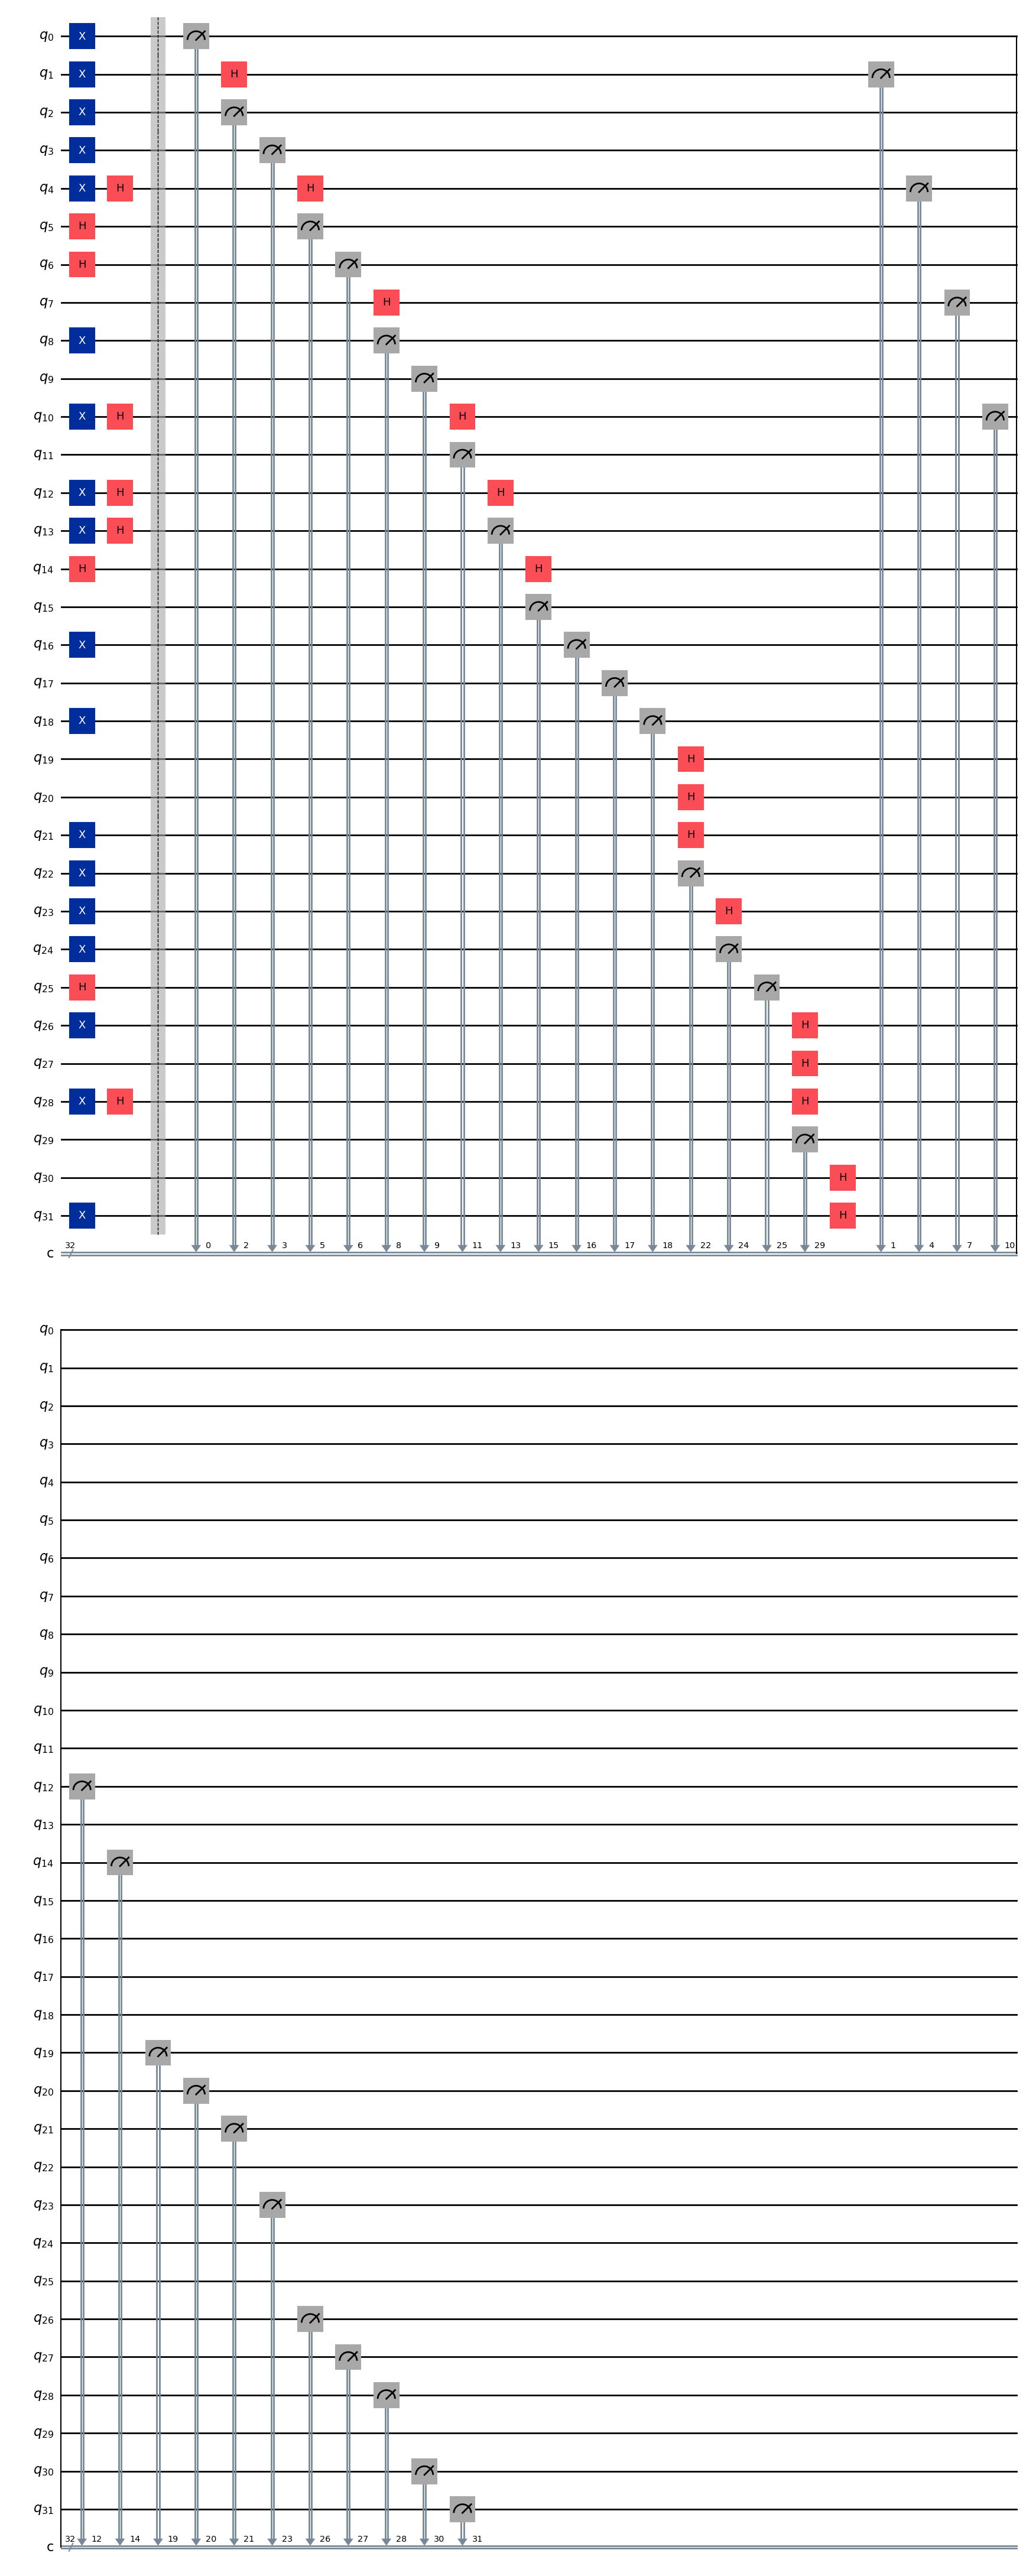

In [ ]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.visualization import circuit_drawer
import matplotlib.pyplot as plt

n = 32

def sarg04_circuit(n):
    # Random bit and basis generation for Alice
    alice_bits = np.random.randint(2, size=n)
    alice_bases = np.random.randint(2, size=n)  # 0 = Z basis, 1 = X basis
    bob_bases = np.random.randint(2, size=n)

    print(f"Alice's Bits:   {alice_bits}")
    print(f"Alice's Bases:  {['Z' if b == 0 else 'X' for b in alice_bases]}")
    print(f"Bob's Bases:    {['Z' if b == 0 else 'X' for b in bob_bases]}")

    # Create quantum circuit
    qc = QuantumCircuit(n, n)

    # Alice's preparation
    for i in range(n):
        if alice_bits[i] == 1:
            qc.x(i)  # Bit value
        if alice_bases[i] == 1:
            qc.h(i)  # X basis uses Hadamard

    qc.barrier()

    # Bob's measurement
    for i in range(n):
        if bob_bases[i] == 1:
            qc.h(i)
        qc.measure(i, i)

    return qc

# Generate and draw the SARG04 circuit for 8 bits
qc_sarg04 = sarg04_circuit(n)
qc_sarg04.draw("mpl")


In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit

# Number of bits
n = 16

# Step 1: Alice's bit and basis generation
alice_bits = [random.randint(0, 1) for _ in range(n)]
alice_bases = [random.choice(['z', 'x']) for _ in range(n)]

# Mapping from bit+basis to quantum state
def get_qubit_state(bit, basis):
    if basis == 'z':
        return '|0>' if bit == 0 else '|1>'
    else:
        return '|+>' if bit == 0 else '|->'

# State pairs used in SARG04
state_pairs = {
    '|0>': ['|0>', '|+>'],
    '|1>': ['|1>', '|->'],
    '|+>': ['|+>', '|0>'],
    '|->': ['|->', '|1>']
}

# Step 2: Bob's measurement bases
bob_bases = [random.choice(['z', 'x']) for _ in range(n)]
bob_results = []

# Simulate measurement (idealized)
def measure_state(state, bob_basis):
    if state == '|0>':
        return 0 if bob_basis == 'z' else random.choice([0, 1])
    elif state == '|1>':
        return 1 if bob_basis == 'z' else random.choice([0, 1])
    elif state == '|+>':
        return 0 if bob_basis == 'x' else random.choice([0, 1])
    elif state == '|->':
        return 1 if bob_basis == 'x' else random.choice([0, 1])

# Simulate transmission
alice_states = [get_qubit_state(bit, basis) for bit, basis in zip(alice_bits, alice_bases)]
for i in range(n):
    result = measure_state(alice_states[i], bob_bases[i])
    bob_results.append(result)

# Step 3: Sifting
announced_pairs = [state_pairs[state] for state in alice_states]
matched_indices = []
raw_key = []
unmatched_indices = []

for i in range(n):
    pair = announced_pairs[i]
    measured = bob_results[i]
    bob_basis = bob_bases[i]

    if bob_basis == 'z':
        outcome = '|0>' if measured == 0 else '|1>'
    else:
        outcome = '|+>' if measured == 0 else '|->'

    if outcome in pair and pair.count(outcome) == 1:
        matched_indices.append(i)
        raw_key.append(alice_bits[i])
    else:
        unmatched_indices.append(i)

# Error rate
matched_bits = len(matched_indices)
unmatched_bits = len(unmatched_indices)
error_rate = (unmatched_bits / matched_bits) * 100 if matched_bits > 0 else 0

# Final printout in SARG04-style
print("\n--- SARG04 Simulation Summary ---")
print(f"Alice Bits:       {alice_bits}")
print(f"Alice Bases:      {alice_bases}")
print(f"Alice States:     {alice_states}")
print(f"Bob Bases:        {bob_bases}")
print(f"Bob Results:      {bob_results}")
print(f"Sifted Indices:   {matched_indices}")
print(f"Sifted Key:       {raw_key}")
print(f"Matched Bits:     {matched_bits}")
print(f"Unmatched Bits:   {unmatched_bits}")
print(f"Error Rate: {error_rate:.2f}%")

# Optional visualization
plt.figure(figsize=(12, 6))

# Plot matched indices in green
plt.bar(matched_indices, [1]*len(matched_indices), color='green', label='Matched')

# Plot unmatched indices in red
plt.bar(unmatched_indices, [1]*len(unmatched_indices), color='red', label='Unmatched')

plt.title("SARG04 Matched vs. Unmatched Indices")
plt.xlabel("Qubit Index")
plt.ylabel("Status (1 = Present)")
plt.yticks([])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'qiskit'